In [1]:
from pennylane import numpy as np
import pennylane as qml
import itertools
from itertools import combinations
from scipy.optimize import minimize
from math import comb

In [29]:
def make_dicke_state(n, k):
        if k < 0 or k > n:
            raise ValueError("k must satisfy 0 <= k <= n")
    
        state = np.zeros(2**n, dtype=complex)
        weight_k_states = list(combinations(range(n), k))
        
        amplitude = 1 / np.sqrt(len(weight_k_states))

        #convert bit string to integer
        for one_positions in weight_k_states:
            basis_index=0
            for wire in one_positions:
                basis_index+=2**(n-1-wire)
            state[basis_index] = amplitude

        

        d_state = np.array(state, requires_grad=False)
        if (comb(n,k)!=np.count_nonzero(d_state)):
            raise ValueError("amplitude count incorrect")
    
        return d_state

In [30]:
def clique_expansion(hyperedges):
    mixer_edges = set()

    for edge in hyperedges:
        for u, v in itertools.combinations(edge, 2):
            mixer_edges.add(tuple(sorted((u, v))))

    return sorted(mixer_edges)

In [31]:
def build_cost_terms(hyperedge_list):
    """
    Returns a list of expanded even-order Z terms.

    Each entry:
        (hyperedge_idx, wires, coefficient) where wires is a tuple such as (0, 2) or (0, 1, 2, 3).
    """
    cost_terms = []

    for edge_idx, edge in enumerate(hyperedge_list):
        edge = tuple(edge)
        k = len(edge)

        # All nonconstant terms have the same coefficient
        coeff = -1 / (2 ** (k - 1))

        # Keep only even-order Z products: 2, 4, 6, ...
        for order in range(2, k + 1, 2):
            for wires in combinations(edge, order):
                cost_terms.append(
                    (edge_idx, wires, coeff)
                )

    return cost_terms

In [32]:
def U_B(beta,edge_list):
    for edge_idx, (u, v) in enumerate(edge_list):
        theta = beta[edge_idx]
        qml.S(wires=u)
        qml.SingleExcitationMinus(-2 * theta,wires=[u, v])
        qml.adjoint(qml.S)(wires=u)

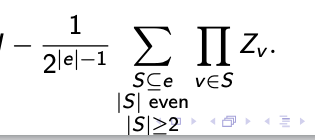

In [90]:
def U_C(gamma,cost_terms):
    for term_idx, (_, wires, coeff) in enumerate(cost_terms):
        theta = 2 * gamma[term_idx] * coeff
        # example for 4 consectuve z's
        #qml.PauliRot(theta, "ZZZZ", wires=[0,1,2,3])
        qml.PauliRot(theta,"Z" * len(wires),wires=list(wires))

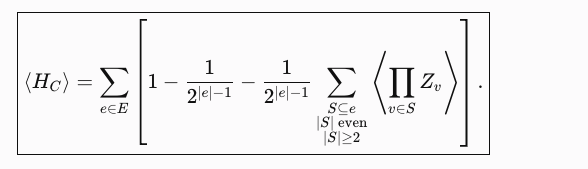

In [67]:
def objective(gammas,betas,circuit,hyperedge_list,cost_terms):
    expectation_values = circuit(gammas, betas)
    value = 0.0

    for edge in hyperedge_list:
        k = len(edge)
        value += 1 - 1 / (2 ** (k - 1))

    for term_idx, (_, _, coeff) in enumerate(cost_terms):
        value += coeff * expectation_values[term_idx]

    return value

In [43]:
# Example small test hypergraph
hyperedge_list = [
    [0, 1, 2, 3]
]

n_wires = 4
num_layers = 1
seed = 42

rng = np.random.default_rng(seed)

edge_list = clique_expansion(hyperedge_list)
cost_terms = build_cost_terms(hyperedge_list)

num_mixer_edges = len(edge_list)
num_cost_terms = len(cost_terms)

target_weight = n_wires // 2
initial_state = make_dicke_state(n_wires, target_weight)

dev = qml.device("default.qubit", wires=n_wires)

print("Mixer edges:", edge_list)
print("Number of mixer parameters/layer:", num_mixer_edges)
print("Number of cost parameters/layer:", num_cost_terms)

Mixer edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
Number of mixer parameters/layer: 6
Number of cost parameters/layer: 7


In [44]:
scaling_constant = 0.1

beta_params = scaling_constant * rng.random(
    (num_mixer_edges, num_layers)
)

gamma_params = scaling_constant * rng.random(
    (num_cost_terms, num_layers)
)

beta_params = np.array(beta_params, requires_grad=True)
gamma_params = np.array(gamma_params, requires_grad=True)

print("beta shape:", beta_params.shape)
print("gamma shape:", gamma_params.shape)

beta shape: (6, 1)
gamma shape: (7, 1)


In [68]:
# n_wires = 6
# dev = qml.device("default.qubit", wires=n_wires)
# @qml.qnode(dev)
# def circuit(gammas, betas):

#     qml.StatePrep(initial_state,wires=range(n_wires))

#     for layer in range(num_layers):
#         U_C(gammas[:, layer],cost_terms)
#         U_B(betas[:, layer],edge_list)

#     observables = []

#     for _, wires, _ in cost_terms:
#         z_term = qml.prod(*[qml.PauliZ(wire) for wire in wires])
#         observables.append(qml.expval(z_term))

#     return observables

In [46]:
# expectation_values = circuit(gamma_params,beta_params)
# print(expectation_values)

[tensor(-0.32867364, requires_grad=True), tensor(-0.33271289, requires_grad=True), tensor(-0.33861347, requires_grad=True), tensor(-0.33861347, requires_grad=True), tensor(-0.33271289, requires_grad=True), tensor(-0.32867364, requires_grad=True), tensor(1., requires_grad=True)]


In [48]:
# step_size = 0.05
# max_trials = 100

# opt = qml.AdamOptimizer(
#     stepsize=step_size
# )

# objective_list = [
#     objective(
#         gamma_params,
#         beta_params,
#         circuit,
#         hyperedge_list,
#         cost_terms
#     )
# ]

In [49]:
# for trial in range(max_trials):

#     gamma_params, beta_params = opt.step(
#         lambda g, b: objective(
#             g,
#             b,
#             circuit,
#             hyperedge_list,
#             cost_terms
#         ),
#         gamma_params,
#         beta_params
#     )

#     current_objective = objective(
#         gamma_params,
#         beta_params,
#         circuit,
#         hyperedge_list,
#         cost_terms
#     )

#     objective_list.append(
#         current_objective
#     )

#     if trial % 10 == 0:
#         print(
#             f"Iteration {trial:3d} | "
#             f"cut = {-current_objective:.6f}"
#         )

Iteration   0 | cut = 1.000000
Iteration  10 | cut = 1.000000
Iteration  20 | cut = 1.000000
Iteration  30 | cut = 1.000000
Iteration  40 | cut = 1.000000
Iteration  50 | cut = 1.000000
Iteration  60 | cut = 1.000000
Iteration  70 | cut = 1.000000
Iteration  80 | cut = 1.000000
Iteration  90 | cut = 1.000000


In [50]:
# Test 1

hyperedge_list = [
    [0, 1],
    [1, 2],
    [2, 3]
]

n_wires = 4
num_layers = 1

edge_list = clique_expansion(hyperedge_list)
cost_terms = build_cost_terms(hyperedge_list)

print("edge_list:", edge_list)
print("cost_terms:", cost_terms)

edge_list: [(0, 1), (1, 2), (2, 3)]
cost_terms: [(0, (0, 1), -0.5), (1, (1, 2), -0.5), (2, (2, 3), -0.5)]


In [51]:
# Test 2

hyperedge_list = [
    [0, 1, 2, 3]
]

n_wires = 8
num_layers = 1

edge_list = clique_expansion(hyperedge_list)
cost_terms = build_cost_terms(hyperedge_list)

print("number of mixer edges:", len(edge_list))
print("number of cost terms:", len(cost_terms))

for term in cost_terms:
    print(term)

number of mixer edges: 6
number of cost terms: 7
(0, (0, 1), -0.125)
(0, (0, 2), -0.125)
(0, (0, 3), -0.125)
(0, (1, 2), -0.125)
(0, (1, 3), -0.125)
(0, (2, 3), -0.125)
(0, (0, 1, 2, 3), -0.125)


In [52]:
# Test 3

hyperedge_list = [
    [0, 1],
    [1, 2, 3],
    [0, 2, 4, 5]
]

n_wires = 6
num_layers = 1

edge_list = clique_expansion(hyperedge_list)
cost_terms = build_cost_terms(hyperedge_list)

print("number of mixer edges:", len(edge_list))
print("number of cost terms:", len(cost_terms))

for term in cost_terms:
    print(term)

number of mixer edges: 10
number of cost terms: 11
(0, (0, 1), -0.5)
(1, (1, 2), -0.25)
(1, (1, 3), -0.25)
(1, (2, 3), -0.25)
(2, (0, 2), -0.125)
(2, (0, 4), -0.125)
(2, (0, 5), -0.125)
(2, (2, 4), -0.125)
(2, (2, 5), -0.125)
(2, (4, 5), -0.125)
(2, (0, 2, 4, 5), -0.125)


In [53]:
# Test 4: overlapping hyperedges

hyperedge_list = [
    [0, 1, 2, 3],
    [2, 3, 4, 5]
]

n_wires = 6
num_layers = 1

edge_list = clique_expansion(hyperedge_list)
cost_terms = build_cost_terms(hyperedge_list)

print("number of mixer edges:", len(edge_list))
print("number of cost terms:", len(cost_terms))

number of mixer edges: 11
number of cost terms: 14


In [62]:
hyperedge_list = [
    [0, 1],
    [1, 2, 3],
    [0, 2, 4, 5]
]

n_wires = 6
num_layers = 1

edge_list = clique_expansion(hyperedge_list)
cost_terms = build_cost_terms(hyperedge_list)

target_weight = n_wires // 2
initial_state = make_dicke_state(n_wires, target_weight)

dev = qml.device("default.qubit", wires=n_wires)

In [69]:
seed = 42
rng = np.random.default_rng(seed)

scaling_constant = 0.1

beta_params = np.array(
    scaling_constant * rng.random(
        (len(edge_list), num_layers)
    ),
    requires_grad=True
)

gamma_params = np.array(
    scaling_constant * rng.random(
        (len(cost_terms), num_layers)
    ),
    requires_grad=True
)

print("beta params:", beta_params.shape)
print("gamma params:", gamma_params.shape)

beta params: (10, 1)
gamma params: (11, 1)


In [70]:
print(circuit(gamma_params, beta_params))

[tensor(-0.18833295, requires_grad=True), tensor(-0.19271889, requires_grad=True), tensor(-0.20153865, requires_grad=True), tensor(-0.19414114, requires_grad=True), tensor(-0.2090427, requires_grad=True), tensor(-0.19667628, requires_grad=True), tensor(-0.19829638, requires_grad=True), tensor(-0.2043077, requires_grad=True), tensor(-0.19978957, requires_grad=True), tensor(-0.19342602, requires_grad=True), tensor(0.20153865, requires_grad=True)]


In [71]:
initial_value = objective(
    gamma_params,
    beta_params,
    circuit,
    hyperedge_list,
    cost_terms
)

print("Initial cut value:", -initial_value)

Initial cut value: -2.49126614765965


In [73]:
opt = qml.AdamOptimizer(stepsize=0.05)

for trial in range(100):

    gamma_params, beta_params = opt.step(
        lambda g, b: objective(
            g,
            b,
            circuit,
            hyperedge_list,
            cost_terms
        ),
        gamma_params,
        beta_params
    )

    if trial % 10 == 0:
        current_value = objective(
            gamma_params,
            beta_params,
            circuit,
            hyperedge_list,
            cost_terms
        )

        print(
            f"Iteration {trial:3d} | "
            f"cut = {current_value:.6f}"
        )

Iteration   0 | cut = 2.024322
Iteration  10 | cut = 2.003409
Iteration  20 | cut = 2.001156
Iteration  30 | cut = 2.000062
Iteration  40 | cut = 2.000153
Iteration  50 | cut = 2.000040
Iteration  60 | cut = 2.000016
Iteration  70 | cut = 2.000006
Iteration  80 | cut = 2.000004
Iteration  90 | cut = 2.000001


In [77]:
def run_mincut(
    hyperedge_list,
    n,
    num_layers=1,
    seed=42,
    scaling_constant=0.1,
    step_size=0.05,
    max_trials=100
):
    n_wires=n
    # Build mixer edges and cost terms
    edge_list = clique_expansion(hyperedge_list)
    cost_terms = build_cost_terms(hyperedge_list)

    # Balanced initial state
    target_weight = n_wires // 2
    initial_state = make_dicke_state(n_wires,target_weight)

    # Device
    dev = qml.device("default.qubit",wires=n_wires)

    # Circuit must be created for this device
    @qml.qnode(dev)
    def circuit(gammas, betas):
        qml.StatePrep(initial_state,wires=range(n_wires))

        for layer in range(num_layers):
            U_C(gammas[:, layer],cost_terms)

            U_B(betas[:, layer],edge_list)

        observables = []

        for _, wires, _ in cost_terms:
            z_term = qml.prod(*[qml.PauliZ(wire)for wire in wires])
            observables.append(qml.expval(z_term))
        return observables

    # Random parameter initialization
    rng = np.random.default_rng(seed)

    beta_params = np.array(scaling_constant * rng.random((len(edge_list), num_layers)),requires_grad=True)

    gamma_params = np.array(scaling_constant * rng.random((len(cost_terms), num_layers)),requires_grad=True)

    # Optimizer
    opt = qml.AdamOptimizer(stepsize=step_size)

    objective_values = []

    # Initial value
    initial_value = objective(gamma_params,beta_params,circuit,hyperedge_list,cost_terms)

    objective_values.append(initial_value)

    print(f"Initial cut = {initial_value:.6f}")

    # Optimization
    for trial in range(max_trials):

        gamma_params, beta_params = opt.step(
            lambda g, b: objective(
                g,
                b,
                circuit,
                hyperedge_list,
                cost_terms
            ),
            gamma_params,
            beta_params
        )

        current_value = objective(
            gamma_params,
            beta_params,
            circuit,
            hyperedge_list,
            cost_terms
        )

        objective_values.append(
            current_value
        )

        if trial % 10 == 0:
            print(
                f"Iteration {trial:3d} | "
                f"cut = {current_value:.6f}"
            )

    return {
        "gammas": gamma_params,
        "betas": beta_params,
        "objective_values": objective_values,
        "circuit": circuit,
        "edge_list": edge_list,
        "cost_terms": cost_terms,
        "n_wires": n_wires
    }

In [80]:
test_graph = [
    [0, 1],
    [1, 2, 3],
    [0, 2, 4, 5]
]

result = run_mincut(
    test_graph,
    n=6,
    num_layers=1,
    max_trials=100
)

Initial cut = 2.491266
Iteration   0 | cut = 2.464660
Iteration  10 | cut = 2.180809
Iteration  20 | cut = 2.023564
Iteration  30 | cut = 2.004649
Iteration  40 | cut = 2.006399
Iteration  50 | cut = 2.001149
Iteration  60 | cut = 2.000657
Iteration  70 | cut = 2.000350
Iteration  80 | cut = 2.000056
Iteration  90 | cut = 2.000045


In [81]:
def matrix_to_hyperedges(P):
    hyperedge_list = []

    for edge_idx in range(P.shape[1]):
        vertices = np.nonzero(P[:, edge_idx])[0]
        hyperedge_list.append(vertices.tolist())

    return hyperedge_list

In [82]:
P = np.load("data/poisson_16_12_3/P/03.npy")

hyperedge_list = matrix_to_hyperedges(P)

print("shape:", P.shape)
print("number of hyperedges:", len(hyperedge_list))
print("hyperedges:")

for edge in hyperedge_list:
    print(edge)

shape: (12, 16)
number of hyperedges: 16
hyperedges:
[1, 2]
[3, 5, 8]
[7, 8]
[1, 4, 5]
[2, 6, 7, 8]
[0, 1, 3]
[1, 5, 8]
[6, 7, 11]
[6, 7]
[2, 3, 9, 10]
[3, 8, 9]
[1, 5, 9]
[1, 6, 9]
[2, 5, 10]
[2, 5, 8, 9]
[1, 5, 7, 10]


In [83]:
print("Mixer edges:", len(clique_expansion(hyperedge_list)))
print("Cost terms:", len(build_cost_terms(hyperedge_list)))

for i, edge in enumerate(hyperedge_list):
    print(i, edge, "size =", len(edge))

Mixer edges: 36
Cost terms: 58
0 [1, 2] size = 2
1 [3, 5, 8] size = 3
2 [7, 8] size = 2
3 [1, 4, 5] size = 3
4 [2, 6, 7, 8] size = 4
5 [0, 1, 3] size = 3
6 [1, 5, 8] size = 3
7 [6, 7, 11] size = 3
8 [6, 7] size = 2
9 [2, 3, 9, 10] size = 4
10 [3, 8, 9] size = 3
11 [1, 5, 9] size = 3
12 [1, 6, 9] size = 3
13 [2, 5, 10] size = 3
14 [2, 5, 8, 9] size = 4
15 [1, 5, 7, 10] size = 4


In [87]:
result = run_mincut(
    hyperedge_list,
    n=12,
    num_layers=2,
    seed=42,
    scaling_constant=0.1,
    step_size=0.05,
    max_trials=200
)

Initial cut = 12.435470
Iteration   0 | cut = 12.011105
Iteration  10 | cut = 10.618463
Iteration  20 | cut = 10.088327
Iteration  30 | cut = 9.623871
Iteration  40 | cut = 9.333489
Iteration  50 | cut = 9.112850
Iteration  60 | cut = 8.891196
Iteration  70 | cut = 8.693596
Iteration  80 | cut = 8.563591
Iteration  90 | cut = 8.502214
Iteration 100 | cut = 8.470240
Iteration 110 | cut = 8.423861
Iteration 120 | cut = 8.358389
Iteration 130 | cut = 8.313420
Iteration 140 | cut = 8.273675
Iteration 150 | cut = 8.237228
Iteration 160 | cut = 8.214486
Iteration 170 | cut = 8.195486
Iteration 180 | cut = 8.175365
Iteration 190 | cut = 8.153654


In [88]:
test_cases = {
    "k=3": {
        "hyperedge_list": [[0, 1, 2]],
        "n": 3
    },
    "k=4": {
        "hyperedge_list": [[0, 1, 2, 3]],
        "n": 4
    },
    "k=5": {
        "hyperedge_list": [[0, 1, 2, 3, 4]],
        "n": 5
    }
}

In [89]:
for name, case in test_cases.items():

    hyperedge_list = case["hyperedge_list"]
    n_wires = case["n"]
    num_layers = 1

    edge_list = clique_expansion(hyperedge_list)
    cost_terms = build_cost_terms(hyperedge_list)

    target_weight = n_wires // 2
    initial_state = make_dicke_state(n_wires, target_weight)

    dev = qml.device("default.qubit", wires=n_wires)

    rng = np.random.default_rng(42)

    beta_params = np.array(
        0.1 * rng.random((len(edge_list), num_layers)),
        requires_grad=True
    )

    gamma_params = np.array(
        0.1 * rng.random((len(cost_terms), num_layers)),
        requires_grad=True
    )

    @qml.qnode(dev)
    def test_circuit(gammas, betas):
        qml.StatePrep(initial_state, wires=range(n_wires))

        U_C(gammas[:, 0], cost_terms)
        U_B(betas[:, 0], edge_list)

        return qml.state()

    print("\n", "=" * 50)
    print(name)
    print("cost terms:", len(cost_terms))
    print("mixer edges:", len(edge_list))
    print("=" * 50)

    print(
        qml.draw(test_circuit)(
            gamma_params,
            beta_params
        )
    )


k=3
cost terms: 3
mixer edges: 3
0: ─╭|Ψ⟩─╭RZZ(-0.03)─╭RZZ(-0.00)──S──────────╭G₋(-0.15)──S†──S─╭G₋(-0.09)──S†────────────────┤ ···
1: ─├|Ψ⟩─╰RZZ(-0.03)─│───────────╭RZZ(-0.05)─╰G₋(-0.15)────────│───────────S──╭G₋(-0.17)──S†─┤ ···
2: ─╰|Ψ⟩─────────────╰RZZ(-0.00)─╰RZZ(-0.05)───────────────────╰G₋(-0.09)─────╰G₋(-0.17)─────┤ ···

0: ···   State
1: ···   State
2: ···   State

k=4
cost terms: 7
mixer edges: 6
0: ─╭|Ψ⟩─╭RZZ(-0.02)─╭RZZ(-0.02)─╭RZZ(-0.00)─────────────────────────────────────╭RZZZZ(-0.02) ···
1: ─├|Ψ⟩─╰RZZ(-0.02)─│───────────│───────────╭RZZ(-0.01)─╭RZZ(-0.01)─────────────├RZZZZ(-0.02) ···
2: ─├|Ψ⟩─────────────╰RZZ(-0.02)─│───────────╰RZZ(-0.01)─│───────────╭RZZ(-0.02)─├RZZZZ(-0.02) ···
3: ─╰|Ψ⟩─────────────────────────╰RZZ(-0.00)─────────────╰RZZ(-0.01)─╰RZZ(-0.02)─╰RZZZZ(-0.02) ···

0: ··· ──S─╭G₋(-0.15)──S†──S─╭G₋(-0.09)──S†──S─╭G₋(-0.17)──S†───────────────────────────────── ···
1: ··· ────╰G₋(-0.15)────────│─────────────────│───────────S──╭G₋(-0.14)──S†──S─╭G₋(-0.02)──S